# Centrifugal pump: SRF vs MRF



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# quick case used in the report (SRF: f=None, MRF: f=0.5)
# set nr=80, ntheta=160, rpm=2000, Re=500, swirl=0.85, htc=120, f=0.55 for the lab case
quick = dict(nr=20, ntheta=32, rpm=1500, Re=300, swirl=0.8, htc=100, loss=0.04, Tin=300, Twall=330)
f_mrf = 0.5

Solver (one function for both models: `f=None` gives SRF, `f=0.5` gives MRF with the interface at that fraction of the passage)

In [2]:
def solve(nr, ntheta, rpm, Re, swirl, htc, loss, Tin, Twall, f=None):
    r1, r2, b = 0.030, 0.120, 0.010
    rho, mu, cp, k, g = 997.0, 1e-3, 4180.0, 0.6, 9.81
    Om = rpm * 2 * np.pi / 60
    ur1 = Re * mu / (rho * 2 * b)

    r = np.linspace(r1, r2, nr)
    th = np.linspace(0, 2 * np.pi, ntheta, endpoint=False)
    dr, dth = r[1] - r[0], th[1] - th[0]

    # prescribed velocities
    ur = ur1 * r1 / r
    if f is None:                                  # SRF: one rotating zone
        rotor = np.ones(nr, bool)
        ut = swirl * Om * r
        r_mrf = None
    else:                                          # MRF: rotor + stator, interface on a grid line
        i_m = min(max(int(round(f * (nr - 1))), 2), nr - 3)
        r_mrf = r[i_m]
        rotor = r <= r_mrf
        C = swirl * Om * r_mrf**2
        ut = np.where(rotor, swirl * Om * r, C / r)
    Oz = np.where(rotor, Om, 0.0)                  # frame rotation rate of each zone
    w = ut - Oz * r                                # relative tangential velocity

    # pressure: forward difference and closed form
    p = np.zeros(nr)
    p[1:] = np.cumsum(dr * (rho * ut**2 / r - 12 * mu * ur / b**2)[:-1])
    fr = lambda rr, ra: 12 * mu * ur1 * r1 * np.log(rr / ra) / b**2
    pe = 0.5 * rho * swirl**2 * Om**2 * (r**2 - r1**2) - fr(r, r1)
    if f is not None:
        p_m = 0.5 * rho * swirl**2 * Om**2 * (r_mrf**2 - r1**2) - fr(r_mrf, r1)
        st = ~rotor
        pe[st] = p_m + 0.5 * rho * C**2 * (1 / r_mrf**2 - 1 / r[st]**2) - fr(r[st], r_mrf)

    # temperature: A T = rhs (upwind advection, central diffusion, wall exchange)
    alpha = k / (rho * cp)
    beta = 2 * htc / (rho * cp * b)
    src = loss * np.abs(ur) * (Oz * r) ** 2 / (b * cp)
    A = lil_matrix((nr * ntheta, nr * ntheta))
    rhs = np.zeros(nr * ntheta)
    idx = lambda i, j: i * ntheta + j
    for j in range(ntheta):
        A[idx(0, j), idx(0, j)] = 1.0
        rhs[idx(0, j)] = Tin                       # inlet: T = Tin
        A[idx(nr-1, j), idx(nr-1, j)] = 3.0        # outlet: dT/dr = 0 (second order)
        A[idx(nr-1, j), idx(nr-2, j)] = -4.0
        A[idx(nr-1, j), idx(nr-3, j)] = 1.0
    for i in range(1, nr - 1):
        ar, at = alpha / dr**2, alpha / (r[i]**2 * dth**2)
        v = w[i] / r[i]
        aW = ar + max(ur[i], 0) / dr
        aE = ar + max(-ur[i], 0) / dr
        aS = at + max(v, 0) / dth
        aN = at + max(-v, 0) / dth
        for j in range(ntheta):
            row = idx(i, j)
            A[row, row] = aW + aE + aS + aN + beta
            A[row, idx(i-1, j)] = -aW
            A[row, idx(i+1, j)] = -aE
            A[row, idx(i, (j-1) % ntheta)] = -aS
            A[row, idx(i, (j+1) % ntheta)] = -aN
            rhs[row] = beta * Twall + src[i]
    T = spsolve(A.tocsr(), rhs).reshape(nr, ntheta)

    mdot = rho * ur1 * 2 * np.pi * r1 * b
    Tout = T[-1].mean()
    return dict(r=r, th=th, T=T, p=p, pe=pe, ut=ut, w=w, ur=ur, r_mrf=r_mrf,
                dp=p[-1], head=p[-1] / (rho * g), Tout=Tout,
                heat=mdot * cp * (Tout - Tin), perr=np.abs(p - pe).max(), dp_exact=pe[-1])

Run both cases and compare

In [3]:
srf = solve(**quick)
mrf = solve(**quick, f=f_mrf)

print(f"{'':28s}{'SRF':>12s}{'MRF':>12s}")
for name, key, fmt in [("pressure rise [Pa]", "dp", "{:12.0f}"), ("head [m]", "head", "{:12.3f}"),
                       ("closed-form dp [Pa]", "dp_exact", "{:12.0f}"), ("max pressure error [Pa]", "perr", "{:12.0f}"),
                       ("outlet T [K]", "Tout", "{:12.4f}"), ("heat gain [W]", "heat", "{:12.2f}")]:
    print(f"{name:28s}" + fmt.format(srf[key]) + fmt.format(mrf[key]))
print(f"MRF interface r_mrf = {mrf['r_mrf']:.6f} m")

                                     SRF         MRF
pressure rise [Pa]                102916       67988
head [m]                          10.522       6.951
closed-form dp [Pa]               106272       67569
max pressure error [Pa]             3356        1766
outlet T [K]                    302.0343    302.0252
heat gain [W]                     240.42      239.35
MRF interface r_mrf = 0.077368 m


Figures 1 and 2: domain schematic and tangential velocities

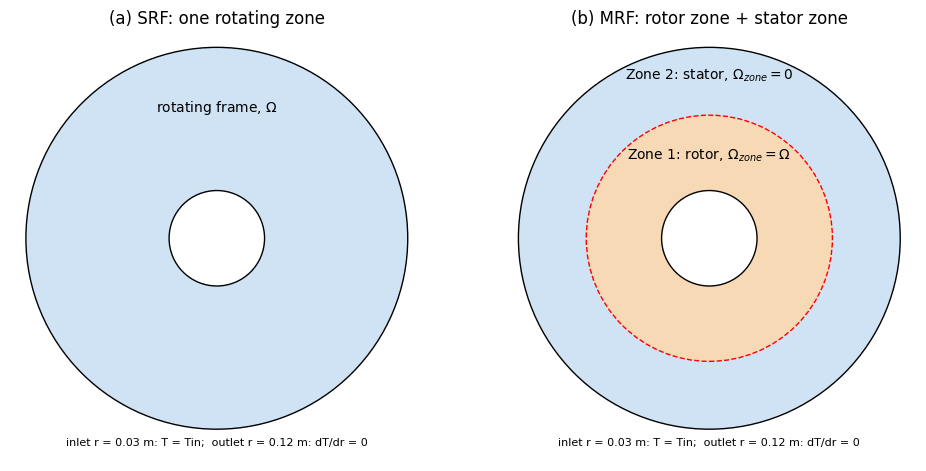

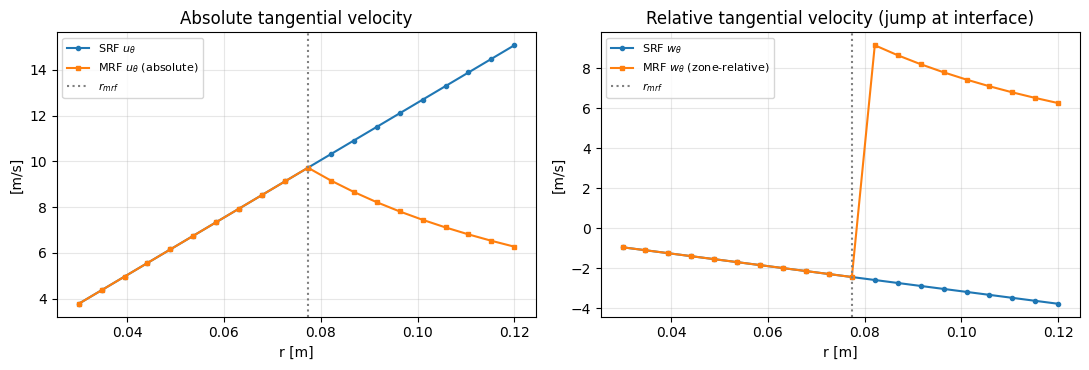

In [4]:
# Fig 1: domain schematic
fig, ax = plt.subplots(1, 2, figsize=(10, 4.8))
for a, title, rm in [(ax[0], "(a) SRF: one rotating zone", None), (ax[1], "(b) MRF: rotor zone + stator zone", mrf["r_mrf"])]:
    a.add_patch(Circle((0, 0), 0.12, fc="#d0e3f5", ec="k"))
    if rm:
        a.add_patch(Circle((0, 0), rm, fc="#f7d9b5", ec="r", ls="--"))
        a.text(0, 0.1, "Zone 2: stator, $\\Omega_{zone}=0$", ha="center")
        a.text(0, 0.05, "Zone 1: rotor, $\\Omega_{zone}=\\Omega$", ha="center")
    else:
        a.text(0, 0.08, "rotating frame, $\\Omega$", ha="center")
    a.add_patch(Circle((0, 0), 0.03, fc="w", ec="k"))
    a.text(0, -0.13, "inlet r = 0.03 m: T = Tin;  outlet r = 0.12 m: dT/dr = 0", ha="center", fontsize=8)
    a.set(xlim=(-0.13, 0.13), ylim=(-0.14, 0.13), aspect="equal", title=title); a.axis("off")
plt.tight_layout(); plt.show()

# Fig 2: tangential velocities
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(srf["r"], srf["ut"], "o-", ms=3, label="SRF $u_\\theta$")
ax[0].plot(mrf["r"], mrf["ut"], "s-", ms=3, label="MRF $u_\\theta$ (absolute)")
ax[0].set(xlabel="r [m]", ylabel="[m/s]", title="Absolute tangential velocity")
ax[1].plot(srf["r"], srf["w"], "o-", ms=3, label="SRF $w_\\theta$")
ax[1].plot(mrf["r"], mrf["w"], "s-", ms=3, label="MRF $w_\\theta$ (zone-relative)")
ax[1].set(xlabel="r [m]", ylabel="[m/s]", title="Relative tangential velocity (jump at interface)")
for a in ax:
    a.axvline(mrf["r_mrf"], color="gray", ls=":", label="$r_{mrf}$")
    a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

Figures 4 and 5: SRF and MRF results

C:\Users\neela\AppData\Local\Temp\ipykernel_22220\4034118471.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax[0].pcolormesh(x, y, res["T"], shading="auto", cmap="inferno")
C:\Users\neela\AppData\Local\Temp\ipykernel_22220\4034118471.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax[2].pcolormesh(x, y, np.hypot(ux, uy), shading="auto", cmap="viridis")


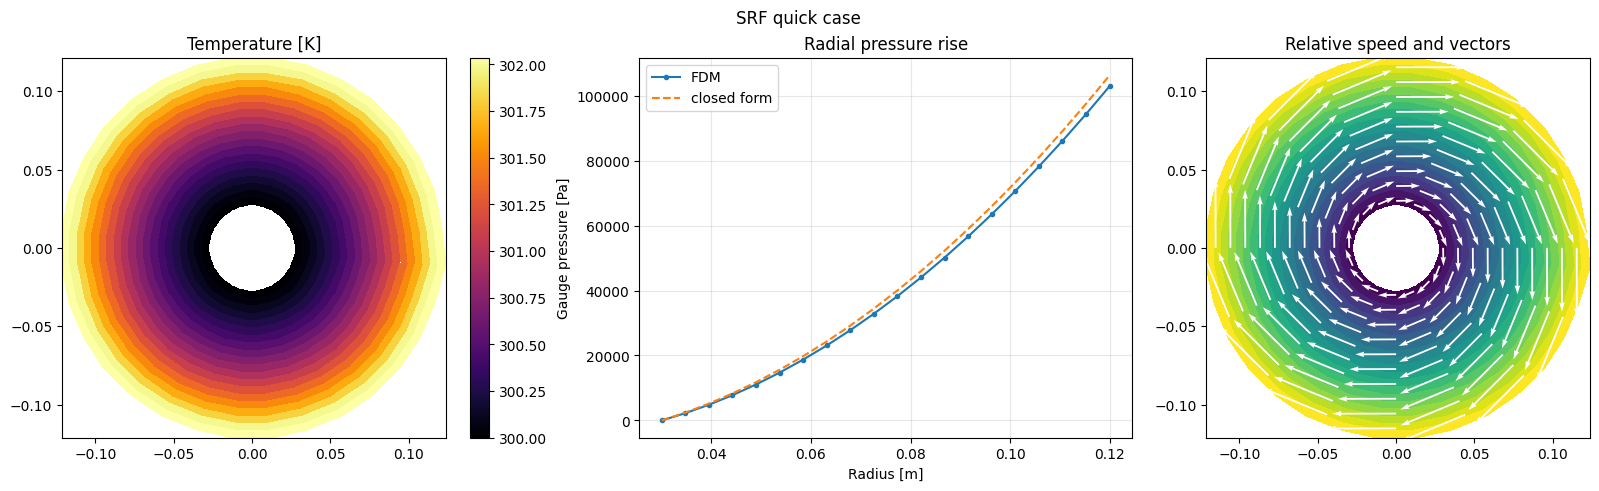

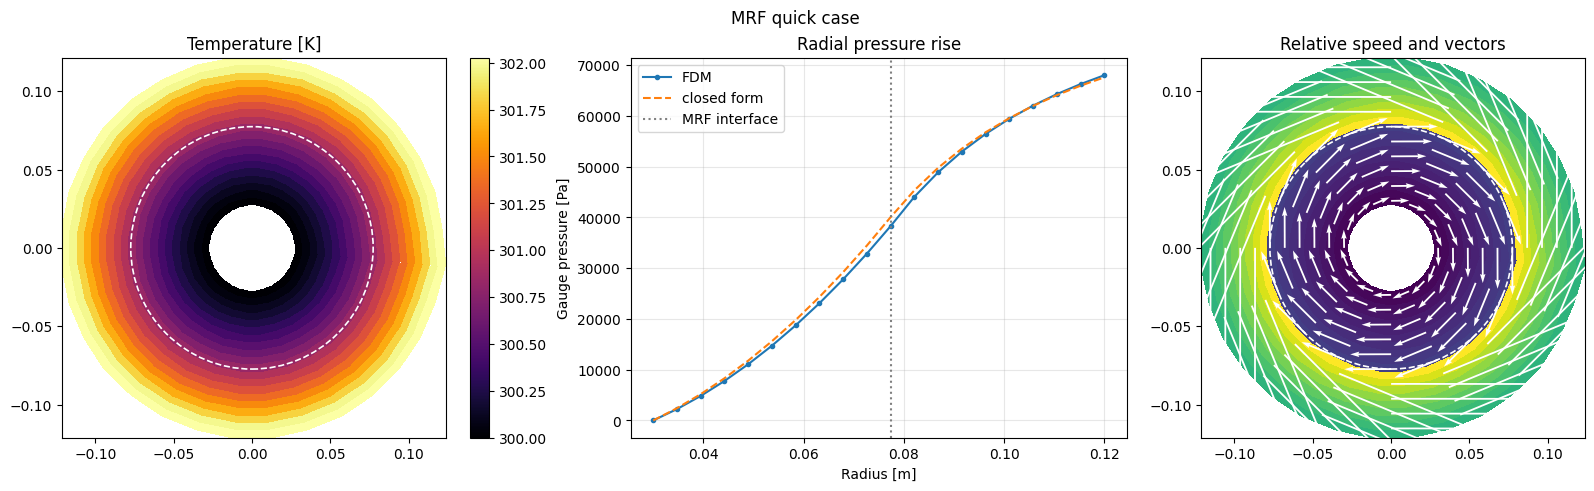

In [5]:
# Fig 4 (SRF) and Fig 5 (MRF): temperature, pressure, relative velocity
def field_plots(res, title):
    r, th = res["r"], res["th"]
    R, TH = np.meshgrid(r, th, indexing="ij")
    x, y = R * np.cos(TH), R * np.sin(TH)
    wr = res["w"][:, None] * np.ones((1, len(th)))
    urr = res["ur"][:, None] * np.ones((1, len(th)))
    ux, uy = urr * np.cos(TH) - wr * np.sin(TH), urr * np.sin(TH) + wr * np.cos(TH)
    rm = res["r_mrf"]

    fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)
    im = ax[0].pcolormesh(x, y, res["T"], shading="auto", cmap="inferno")
    fig.colorbar(im, ax=ax[0]); ax[0].set(title="Temperature [K]", aspect="equal")

    ax[1].plot(r, res["p"], "o-", ms=3, label="FDM")
    ax[1].plot(r, res["pe"], "--", label="closed form")
    if rm: ax[1].axvline(rm, color="gray", ls=":", label="MRF interface")
    ax[1].set(xlabel="Radius [m]", ylabel="Gauge pressure [Pa]", title="Radial pressure rise")
    ax[1].grid(alpha=0.3); ax[1].legend()

    sr, st = max(1, len(r) // 10), max(1, len(th) // 16)
    ax[2].pcolormesh(x, y, np.hypot(ux, uy), shading="auto", cmap="viridis")
    ax[2].quiver(x[::sr, ::st], y[::sr, ::st], ux[::sr, ::st], uy[::sr, ::st], color="white", scale=20)
    ax[2].set(title="Relative speed and vectors", aspect="equal")
    if rm:
        for a in (ax[0], ax[2]):
            a.add_patch(Circle((0, 0), rm, fill=False, ec="white", ls="--", lw=1.2))
    fig.suptitle(title)
    plt.show()

field_plots(srf, "SRF quick case")
field_plots(mrf, "MRF quick case")